# Task 4: Style-conditioned face-to-sketch generation with a conditional GAN

Generator `y_hat = G(x, s)`: U-Net taking a face photo `x` and a learned style embedding `s` (Style 1, 2 or 3).
Discriminator `D(x, s, y)`: PatchGAN judging local patches of (photo, style, sketch) as real or generated.
Generator loss `L_G = L_adv + lambda_L1 * L1(y, G(x, s))`, discriminator loss BCE with logits.

**Before running:** Runtime > Change runtime type > T4 GPU, and the Colab secret `WANDB_API_KEY` (same as Tasks 1 to 3). Task 4 does not depend on Tasks 1 to 3.

| Section | What it does | Approx. time on T4 |
|---|---|---|
| 1 to 3 | Setup, FS2K download, pairing checks, cache, stratified split | 5 to 10 min (first run) |
| 4 | Optuna search (16 trials x 20 epochs, with pruning) | 60 to 100 min |
| 5 | Final training (200 epochs, constant then linear-decay learning rate) | 50 to 80 min |
| 6 to 8 | Curves, test evaluation (SSIM, LPIPS, FID, KID), style analysis, figures | 10 min |
| 9 to 10 | ONNX export, verification, latency, W&B artefacts | 3 min |

Everything is saved to Drive under `genai-assignment1/task4/`, and the Optuna study is in SQLite, so cells can be rerun after a disconnect.

## 1. Setup

In [1]:
!nvidia-smi -L || echo "No GPU found: Runtime > Change runtime type > T4 GPU"
!pip -q install optuna wandb onnx onnxscript onnxruntime pytorch-msssim lpips torchmetrics torch-fidelity gdown

GPU 0: Tesla T4 (UUID: GPU-89b2da94-3f8d-fe19-d47f-5f5a3ed41155)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 754.2/754.2 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 8.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of 

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys
PROJECT_DIR = "/content/drive/MyDrive/genai-assignment1"
for d in ["common", "data", "task4/checkpoints", "task4/onnx", "task4/figures", "task4/results",
          "task4/optuna", "task4/samples"]:
    os.makedirs(os.path.join(PROJECT_DIR, d), exist_ok=True)
open(os.path.join(PROJECT_DIR, "common", "__init__.py"), "a").close()
os.chdir(PROJECT_DIR)
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)
print("Working in", os.getcwd())

Mounted at /content/drive
Working in /content/drive/MyDrive/genai-assignment1


In [3]:
import json, random, time, glob, math, zipfile, shutil
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

SEED = 42
IMG_SIZE = 128
FS2K_ZIP_ON_DRIVE = f"{PROJECT_DIR}/data/FS2K.zip"    # optional manual upload (see Section 2)
FS2K_LOCAL = "/content/fs2k_raw"                      # extracted on fast local disk
CACHE_PATH = f"{PROJECT_DIR}/data/fs2k_128.npz"
SPLIT_PATH = f"{PROJECT_DIR}/data/fs2k_split_seed42.json"
T4 = f"{PROJECT_DIR}/task4"

WANDB_PROJECT = "genai-assignment1"
OPTUNA_TRIALS, OPTUNA_EPOCHS, OPTUNA_EVAL_EVERY = 16, 20, 4
FINAL_EPOCHS, FINAL_EVAL_EVERY, SAMPLE_EVERY = 200, 5, 10
NUM_WORKERS = 2
device = "cuda" if torch.cuda.is_available() else "cpu"

def seed_everything(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
print("Device:", device, "| torch", torch.__version__)

Device: cuda | torch 2.11.0+cu130


## 2. Shared Task 4 code (written to Drive under `common/`)

`fs2k_data.py` (download layout, pairing, cache, stratified split, paired augmentation), `sketch_gan.py` (generator, discriminator, losses) and `gan_train.py` (training and evaluation loops, ONNX wrapper). The repository scripts and the FastAPI backend import the same files.

In [4]:
%%writefile common/fs2k_data.py
"""FS2K data preparation and the paired photo-sketch dataset (Task 4).

Layout of the official release (github.com/DengPingFan/FS2K):
    FS2K/photo/photo{1,2,3}/imageXXXX.(jpg|png)
    FS2K/sketch/sketch{1,2,3}/sketchXXXX.(jpg|png)
    FS2K/anno_train.json, FS2K/anno_test.json   (list of dicts with "image_name" and "style")
The photo -> sketch name mapping follows the authors' tools/split_train_test.py.
"""
import json
import os

import cv2
import numpy as np
import torch
from torch.utils.data import Dataset

STYLE_NAMES = ["Style 1", "Style 2", "Style 3"]
FS2K_GDRIVE_ID = "1saIMhQ3dc5_ftkfGmBPbCluRn_zy7QQp"     # official link in the FS2K README
_EXTS = (".jpg", ".png", ".jpeg", ".JPG", ".PNG", ".JPEG")


def find_fs2k_root(base):
    for root, _, files in os.walk(base):
        if "anno_train.json" in files and "anno_test.json" in files:
            return root
    raise FileNotFoundError(f"No folder containing anno_train.json and anno_test.json under {base}")


def _with_ext(path_no_ext):
    for e in _EXTS:
        if os.path.exists(path_no_ext + e):
            return path_no_ext + e
    return None


def pair_paths(root, image_name):
    """'photo1/image0110' -> (photo path, sketch path). Either may be None if missing."""
    image_name = os.path.splitext(image_name.replace("\\", "/"))[0]
    folder, stem = image_name.split("/")[-2:]
    photo = _with_ext(os.path.join(root, "photo", folder, stem))
    sketch = _with_ext(os.path.join(root, "sketch", folder.replace("photo", "sketch"),
                                    stem.replace("image", "sketch")))
    return photo, sketch


def load_rgb(path, size):
    """Read any FS2K image as RGB uint8 (grayscale expanded, alpha composited on white), resized."""
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise IOError(f"Could not read {path}")
    if img.dtype != np.uint8:
        img = (img / (img.max() or 1) * 255).astype(np.uint8)
    if img.ndim == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    elif img.shape[2] == 4:
        a = img[..., 3:4].astype(np.float32) / 255.0
        img = (img[..., :3].astype(np.float32) * a + 255.0 * (1 - a)).astype(np.uint8)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    else:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    orig_hw = img.shape[:2]
    return cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA), orig_hw


def _load_split(root, anno_file, size):
    anno = json.load(open(os.path.join(root, anno_file)))
    photos, sketches, styles, names = [], [], [], []
    missing, size_mismatch = [], 0
    for a in anno:
        p, s = pair_paths(root, a["image_name"])
        if p is None or s is None:
            missing.append(a["image_name"])
            continue
        pi, phw = load_rgb(p, size)
        si, shw = load_rgb(s, size)
        size_mismatch += int(phw != shw)
        photos.append(pi); sketches.append(si); styles.append(int(a["style"])); names.append(a["image_name"])
    return (np.stack(photos), np.stack(sketches), np.array(styles, np.int64), np.array(names),
            missing, size_mismatch)


def prepare_fs2k_cache(root, cache_path, size=128):
    """Build (or load) a resized cache of the official train and test sets, with pairing checks."""
    if os.path.exists(cache_path):
        d = np.load(cache_path, allow_pickle=False)
        return {k: d[k] for k in d.files}
    out, report = {}, {}
    for split, f in (("train", "anno_train.json"), ("test", "anno_test.json")):
        ph, sk, st, nm, missing, mism = _load_split(root, f, size)
        out.update({f"{split}_photos": ph, f"{split}_sketches": sk, f"{split}_styles": st, f"{split}_names": nm})
        report[split] = {"pairs": int(len(nm)), "missing": missing, "photo_sketch_size_mismatch": mism,
                         "style_counts": np.bincount(st, minlength=3).tolist()}
    np.savez(cache_path, **out)
    with open(os.path.splitext(cache_path)[0] + "_report.json", "w") as fh:
        json.dump(report, fh, indent=2)
    return out


def make_or_load_fs2k_split(styles, path, seed=42, val_frac=0.15):
    """Stratified (by style) train/validation split of the OFFICIAL training portion."""
    if os.path.exists(path):
        s = json.load(open(path))
        return np.array(s["train_idx"]), np.array(s["val_idx"])
    from sklearn.model_selection import train_test_split
    idx = np.arange(len(styles))
    tr, va = train_test_split(idx, test_size=val_frac, random_state=seed, stratify=styles)
    tr, va = np.sort(tr), np.sort(va)
    json.dump({"seed": seed, "val_frac": val_frac, "train_idx": tr.tolist(), "val_idx": va.tolist()},
              open(path, "w"))
    return tr, va


def to_model(img_uint8):
    """HWC uint8 -> CHW float tensor in [-1, 1] (generator uses tanh)."""
    t = torch.from_numpy(np.ascontiguousarray(img_uint8.transpose(2, 0, 1))).float()
    return t / 127.5 - 1.0


def to_unit(t):
    return ((t + 1) / 2).clamp(0, 1)


def paired_augment(photo, sketch, rng, jitter_size=142):
    """Identical spatial transform for both images: resize to jitter_size, same random crop
    back to the original size, same horizontal flip. Keeps pixel correspondence."""
    h, w = photo.shape[:2]
    p = cv2.resize(photo, (jitter_size, jitter_size), interpolation=cv2.INTER_LINEAR)
    s = cv2.resize(sketch, (jitter_size, jitter_size), interpolation=cv2.INTER_LINEAR)
    i = int(rng.integers(0, jitter_size - h + 1)); j = int(rng.integers(0, jitter_size - w + 1))
    p, s = p[i:i + h, j:j + w], s[i:i + h, j:j + w]
    if rng.random() < 0.5:
        p, s = p[:, ::-1], s[:, ::-1]
    return p, s


class PairedSketchDataset(Dataset):
    """Returns (photo, sketch, style) with photo and sketch in [-1, 1]."""

    def __init__(self, photos, sketches, styles, augment=False):
        self.photos, self.sketches, self.styles, self.augment = photos, sketches, styles, augment

    def __len__(self):
        return len(self.photos)

    def __getitem__(self, i):
        p, s = self.photos[i], self.sketches[i]
        if self.augment:
            rng = np.random.default_rng(int(torch.randint(0, 2**31 - 1, (1,)).item()))
            p, s = paired_augment(p, s, rng)
        return to_model(p), to_model(s), int(self.styles[i])

Writing common/fs2k_data.py


In [5]:
%%writefile common/sketch_gan.py
"""Style-conditioned pix2pix (Task 4): U-Net generator + PatchGAN discriminator.

The style condition is a learned nn.Embedding (3 styles). Its vector is expanded to a
spatial map and concatenated to the input of BOTH networks (the 'style-vector expansion'
used by FSGAN, the FS2K authors' model), and again at the generator bottleneck.
"""
import torch
import torch.nn as nn
import torch.nn.functional as F


def style_map(embed, style, h, w):
    e = embed(style)                                  # (N, E)
    return e[:, :, None, None].expand(-1, -1, h, w)


def _down(cin, cout, norm=True):
    layers = [nn.Conv2d(cin, cout, 4, 2, 1, bias=not norm)]
    if norm:
        layers.append(nn.BatchNorm2d(cout))
    layers.append(nn.LeakyReLU(0.2, inplace=True))
    return nn.Sequential(*layers)


def _up(cin, cout, dropout=0.0):
    layers = [nn.ConvTranspose2d(cin, cout, 4, 2, 1, bias=False), nn.BatchNorm2d(cout)]
    if dropout > 0:
        layers.append(nn.Dropout(dropout))
    layers.append(nn.ReLU(inplace=True))
    return nn.Sequential(*layers)


class StyleUNetGenerator(nn.Module):
    """128x128 U-Net with 7 down / 7 up stages (pix2pix 'unet_128'), skip connections at every scale."""

    def __init__(self, base=64, emb_dim=8, dropout=0.5, n_styles=3, in_ch=3, out_ch=3):
        super().__init__()
        c, e = base, emb_dim
        self.embed = nn.Embedding(n_styles, e)
        self.d1 = _down(in_ch + e, c, norm=False)   # 64
        self.d2 = _down(c, 2 * c)                   # 32
        self.d3 = _down(2 * c, 4 * c)               # 16
        self.d4 = _down(4 * c, 8 * c)               # 8
        self.d5 = _down(8 * c, 8 * c)               # 4
        self.d6 = _down(8 * c, 8 * c)               # 2
        self.d7 = _down(8 * c, 8 * c, norm=False)   # 1 (no BatchNorm on a 1x1 map)
        self.u1 = _up(8 * c + e, 8 * c, dropout)    # 2   (style injected again at the bottleneck)
        self.u2 = _up(16 * c, 8 * c, dropout)       # 4
        self.u3 = _up(16 * c, 8 * c, dropout)       # 8
        self.u4 = _up(16 * c, 4 * c)                # 16
        self.u5 = _up(8 * c, 2 * c)                 # 32
        self.u6 = _up(4 * c, c)                     # 64
        self.out = nn.Sequential(nn.ConvTranspose2d(2 * c, out_ch, 4, 2, 1), nn.Tanh())   # 128

    def forward(self, x, style):
        h, w = x.shape[-2:]
        d1 = self.d1(torch.cat([x, style_map(self.embed, style, h, w)], 1))
        d2 = self.d2(d1); d3 = self.d3(d2); d4 = self.d4(d3); d5 = self.d5(d4); d6 = self.d6(d5); d7 = self.d7(d6)
        u = self.u1(torch.cat([d7, style_map(self.embed, style, d7.shape[-2], d7.shape[-1])], 1))
        u = self.u2(torch.cat([u, d6], 1))
        u = self.u3(torch.cat([u, d5], 1))
        u = self.u4(torch.cat([u, d4], 1))
        u = self.u5(torch.cat([u, d3], 1))
        u = self.u6(torch.cat([u, d2], 1))
        return self.out(torch.cat([u, d1], 1))


class StylePatchDiscriminator(nn.Module):
    """70x70 PatchGAN on (photo, sketch, style map). For 128x128 input it outputs a 14x14 logit map."""

    def __init__(self, base=64, emb_dim=8, n_styles=3, photo_ch=3, sketch_ch=3):
        super().__init__()
        c = base
        self.embed = nn.Embedding(n_styles, emb_dim)
        self.net = nn.Sequential(
            nn.Conv2d(photo_ch + sketch_ch + emb_dim, c, 4, 2, 1), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(c, 2 * c, 4, 2, 1, bias=False), nn.BatchNorm2d(2 * c), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(2 * c, 4 * c, 4, 2, 1, bias=False), nn.BatchNorm2d(4 * c), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(4 * c, 8 * c, 4, 1, 1, bias=False), nn.BatchNorm2d(8 * c), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(8 * c, 1, 4, 1, 1))

    def forward(self, photo, sketch, style):
        h, w = photo.shape[-2:]
        return self.net(torch.cat([photo, sketch, style_map(self.embed, style, h, w)], 1))


def init_weights(m):
    """pix2pix initialisation: N(0, 0.02) for convs, N(1, 0.02) for BatchNorm scale."""
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(m.weight, 0.0, 0.02)
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight, 1.0, 0.02); nn.init.zeros_(m.bias)
    elif isinstance(m, nn.Embedding):
        nn.init.normal_(m.weight, 0.0, 1.0)


def build_models(cfg):
    G = StyleUNetGenerator(cfg["base_channels"], cfg["style_emb_dim"], cfg["dropout"])
    D = StylePatchDiscriminator(cfg["base_channels"], cfg["style_emb_dim"])
    G.apply(init_weights); D.apply(init_weights)
    return G, D


def d_losses(D, x, y, y_fake, s):
    """Discriminator BCE-with-logits, real and fake terms returned separately."""
    real, fake = D(x, y, s), D(x, y_fake.detach(), s)
    l_real = F.binary_cross_entropy_with_logits(real, torch.ones_like(real))
    l_fake = F.binary_cross_entropy_with_logits(fake, torch.zeros_like(fake))
    acc_real = (real > 0).float().mean()
    acc_fake = (fake < 0).float().mean()
    return l_real, l_fake, acc_real, acc_fake


def g_losses(D, x, y, y_fake, s):
    """Generator adversarial (non-saturating BCE) and L1 terms. L_G = adv + lambda_L1 * L1."""
    pred = D(x, y_fake, s)
    adv = F.binary_cross_entropy_with_logits(pred, torch.ones_like(pred))
    return adv, F.l1_loss(y_fake, y)


def count_params(m):
    return sum(p.numel() for p in m.parameters())

Writing common/sketch_gan.py


In [6]:
%%writefile common/gan_train.py
"""Training and evaluation loops for the Task 4 conditional GAN (shared by the notebook and scripts)."""
import math
import time

import numpy as np
import torch
from pytorch_msssim import ssim
from torch.utils.data import DataLoader

from .fs2k_data import to_unit
from .sketch_gan import build_models, d_losses, g_losses


def selection_objective(lpips_value, ssim_value):
    """Model selection (lower is better). Fixed and independent of the tuned lambda_L1:
    LPIPS rewards perceptual and texture similarity, (1 - SSIM) rewards structure."""
    return float(lpips_value) + (1.0 - float(ssim_value))


def linear_decay(epochs):
    """pix2pix schedule: constant learning rate for the first half, then linear decay towards 0."""
    start = epochs // 2
    return lambda e: 1.0 if e < start else max(0.0, 1.0 - (e - start + 1) / (epochs - start + 1))


@torch.no_grad()
def generate(G, photos, styles, device, bs=64):
    """photos (N,3,H,W) in [-1,1], styles (N,) long -> generated sketches in [-1,1] on CPU."""
    G.eval()
    out = [G(photos[i:i + bs].to(device), styles[i:i + bs].to(device)).cpu() for i in range(0, len(photos), bs)]
    return torch.cat(out)


@torch.no_grad()
def per_sample_metrics(fake, real, lpips_fn=None, device="cpu", bs=64):
    """fake/real in [-1,1]. L1, PSNR and SSIM on [0,1]; LPIPS (AlexNet) on [-1,1]."""
    f01, r01 = to_unit(fake), to_unit(real)
    l1 = (f01 - r01).abs().flatten(1).mean(1)
    mse = ((f01 - r01) ** 2).flatten(1).mean(1).clamp_min(1e-10)
    psnr = 10 * torch.log10(1.0 / mse)
    s = ssim(f01, r01, data_range=1.0, size_average=False)
    out = {"l1": l1, "psnr": psnr, "ssim": s}
    if lpips_fn is not None:
        lp = [lpips_fn(fake[i:i + bs].to(device), real[i:i + bs].to(device)).flatten().cpu()
              for i in range(0, len(fake), bs)]
        out["lpips"] = torch.cat(lp)
    return out


def evaluate_generator(G, photos, sketches, styles, device, lpips_fn):
    fake = generate(G, photos, styles, device)
    m = per_sample_metrics(fake, sketches, lpips_fn, device)
    summary = {k: float(v.mean()) for k, v in m.items()}
    summary["objective"] = selection_objective(summary["lpips"], summary["ssim"])
    for st in range(3):
        sel = styles == st
        if sel.any():
            summary[f"ssim_style{st + 1}"] = float(m["ssim"][sel].mean())
            summary[f"lpips_style{st + 1}"] = float(m["lpips"][sel].mean())
    return summary, m, fake


def fit_gan(cfg, train_ds, val, epochs, device, lpips_fn, log_fn=None, image_fn=None, trial=None,
            ckpt_path=None, eval_every=5, sample_every=10, num_workers=2, seed=42):
    """Train one configuration.

    val = (photos, sketches, styles) tensors for the validation split.
    Logs the four loss components separately every epoch, validation metrics every eval_every epochs,
    and fixed validation samples every sample_every epochs (through image_fn).
    Returns (best_objective, history, G_with_best_weights_loaded_if_ckpt).
    """
    torch.manual_seed(seed); np.random.seed(seed)
    G, D = build_models(cfg)
    G, D = G.to(device), D.to(device)
    opt_g = torch.optim.Adam(G.parameters(), lr=cfg["lr_g"], betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(D.parameters(), lr=cfg["lr_d"], betas=(0.5, 0.999))
    sch_g = torch.optim.lr_scheduler.LambdaLR(opt_g, linear_decay(epochs))
    sch_d = torch.optim.lr_scheduler.LambdaLR(opt_d, linear_decay(epochs))
    loader = DataLoader(train_ds, batch_size=cfg["batch_size"], shuffle=True, drop_last=True,
                        num_workers=num_workers, pin_memory=torch.cuda.is_available(),
                        persistent_workers=num_workers > 0,
                        generator=torch.Generator().manual_seed(seed))
    lam = cfg["lambda_l1"]
    best, history = math.inf, []
    for epoch in range(1, epochs + 1):
        G.train(); D.train()
        t0 = time.time()
        sums = {k: 0.0 for k in ("d_real", "d_fake", "g_adv", "g_l1", "d_acc_real", "d_acc_fake")}
        n = 0
        for x, y, s in loader:
            x, y, s = x.to(device, non_blocking=True), y.to(device, non_blocking=True), s.to(device)
            fake = G(x, s)
            l_real, l_fake, acc_r, acc_f = d_losses(D, x, y, fake, s)
            opt_d.zero_grad(set_to_none=True)
            (0.5 * (l_real + l_fake)).backward()
            opt_d.step()
            adv, l1 = g_losses(D, x, y, fake, s)
            opt_g.zero_grad(set_to_none=True)
            (adv + lam * l1).backward()
            opt_g.step()
            b = len(x); n += b
            for k, v in (("d_real", l_real), ("d_fake", l_fake), ("g_adv", adv), ("g_l1", l1),
                         ("d_acc_real", acc_r), ("d_acc_fake", acc_f)):
                sums[k] += v.item() * b
        sch_g.step(); sch_d.step()
        rec = {"epoch": epoch, "time_s": time.time() - t0, "lr_g": opt_g.param_groups[0]["lr"],
               **{f"train/{k}": v / n for k, v in sums.items()}}
        if epoch % eval_every == 0 or epoch == epochs:
            summ, _, _ = evaluate_generator(G, *val, device, lpips_fn)
            rec.update({f"val/{k}": v for k, v in summ.items()})
            if summ["objective"] < best:
                best = summ["objective"]
                rec["val/best_objective"] = best
                if ckpt_path:
                    torch.save({"G": G.state_dict(), "D": D.state_dict(), "config": cfg,
                                "epoch": epoch, "val": summ}, ckpt_path)
            if trial is not None:
                import optuna
                trial.report(summ["objective"], epoch)
                if trial.should_prune():
                    raise optuna.TrialPruned()
            print(f"ep {epoch:03d} | D real {rec['train/d_real']:.3f} fake {rec['train/d_fake']:.3f} | "
                  f"G adv {rec['train/g_adv']:.3f} L1 {rec['train/g_l1']:.4f} | val SSIM {summ['ssim']:.4f} "
                  f"LPIPS {summ['lpips']:.4f} obj {summ['objective']:.4f}")
        history.append(rec)
        if log_fn:
            log_fn(rec)
        if image_fn and (epoch == 1 or epoch % sample_every == 0 or epoch == epochs):
            image_fn(G, epoch)
    if ckpt_path:
        G.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=False)["G"])
    return best, history, G


class SketchExportWrapper(torch.nn.Module):
    """ONNX wrapper: photo in [0,1] RGB NCHW + style index (int64, 0..2) -> sketch in [0,1]."""

    def __init__(self, G):
        super().__init__()
        self.G = G

    def forward(self, photo, style):
        return (self.G(photo * 2 - 1, style) + 1) / 2

Writing common/gan_train.py


In [7]:
import importlib
import common.fs2k_data as fd, common.sketch_gan as sg, common.gan_train as gt
for mod in (fd, sg, gt):
    importlib.reload(mod)
from common.fs2k_data import (STYLE_NAMES, FS2K_GDRIVE_ID, find_fs2k_root, prepare_fs2k_cache,
                              make_or_load_fs2k_split, PairedSketchDataset, paired_augment, to_model, to_unit)
from common.sketch_gan import build_models, count_params
from common.gan_train import fit_gan, evaluate_generator, generate, per_sample_metrics, SketchExportWrapper
print("Task 4 modules loaded")

Task 4 modules loaded


## 3. FS2K: download, pairing checks, cache and split

The official archive is downloaded from the Google Drive link in the FS2K README. If that download fails (Google Drive sometimes limits popular files), download `FS2K.zip` yourself from https://github.com/DengPingFan/FS2K, upload it to `MyDrive/genai-assignment1/data/FS2K.zip`, and rerun this cell.

Every annotation entry is matched to its photo and sketch using the authors' naming rule (`photo1/image0110` -> `sketch1/sketch0110`). Missing files and size mismatches are recorded in `data/fs2k_128_report.json`. Both images are resized to 128 x 128 with the same operation. The validation set is 15% of the official training portion, stratified by style, seed 42. The official test set is not touched until Section 7.

In [8]:
if not os.path.exists(CACHE_PATH):
    if not os.path.exists(FS2K_LOCAL):
        zip_path = FS2K_ZIP_ON_DRIVE
        if not os.path.exists(zip_path):
            import gdown
            zip_path = "/content/FS2K.zip"
            gdown.download(id=FS2K_GDRIVE_ID, output=zip_path, quiet=False)
        assert os.path.exists(zip_path), "Download failed: upload FS2K.zip to Drive as described above"
        with zipfile.ZipFile(zip_path) as z:
            z.extractall(FS2K_LOCAL)
    FS2K_ROOT = find_fs2k_root(FS2K_LOCAL)
    print("FS2K root:", FS2K_ROOT)
data = prepare_fs2k_cache(FS2K_ROOT if not os.path.exists(CACHE_PATH) else None, CACHE_PATH, IMG_SIZE)
report = json.load(open(CACHE_PATH.replace(".npz", "_report.json")))
for split, r in report.items():
    print(f"{split}: {r['pairs']} pairs | missing {len(r['missing'])} | photo/sketch size mismatch "
          f"{r['photo_sketch_size_mismatch']} | style counts {r['style_counts']}")

tr_idx, va_idx = make_or_load_fs2k_split(data["train_styles"], SPLIT_PATH, seed=SEED, val_frac=0.15)
P, S, ST = data["train_photos"], data["train_sketches"], data["train_styles"]
train_ds = PairedSketchDataset(P[tr_idx], S[tr_idx], ST[tr_idx], augment=True)

def to_tensors(photos, sketches, styles):
    return (torch.stack([to_model(p) for p in photos]), torch.stack([to_model(s) for s in sketches]),
            torch.as_tensor(styles, dtype=torch.long))

VAL = to_tensors(P[va_idx], S[va_idx], ST[va_idx])
TEST = to_tensors(data["test_photos"], data["test_sketches"], data["test_styles"])
split_tbl = pd.DataFrame({name: np.bincount(st, minlength=3) for name, st in
                          [("train", ST[tr_idx]), ("val", ST[va_idx]), ("test", data["test_styles"])]},
                         index=STYLE_NAMES).T
split_tbl["total"] = split_tbl.sum(1)
split_tbl.to_csv(f"{T4}/results/split_counts.csv"); display(split_tbl)

Downloading...
From (original): https://drive.google.com/uc?id=1saIMhQ3dc5_ftkfGmBPbCluRn_zy7QQp
From (redirected): https://drive.google.com/uc?id=1saIMhQ3dc5_ftkfGmBPbCluRn_zy7QQp&confirm=t&uuid=43c15cfb-5d22-4972-81a5-a6acd1331cbc
To: /content/FS2K.zip
100%|██████████| 110M/110M [00:01<00:00, 100MB/s]


FS2K root: /content/fs2k_raw/FS2K
train: 1058 pairs | missing 0 | photo/sketch size mismatch 0 | style counts [357, 350, 351]
test: 1046 pairs | missing 0 | photo/sketch size mismatch 0 | style counts [619, 381, 46]


,Style 1,Style 2,Style 3,total
train,303,298,298,899
val,54,52,53,159
test,619,381,46,1046


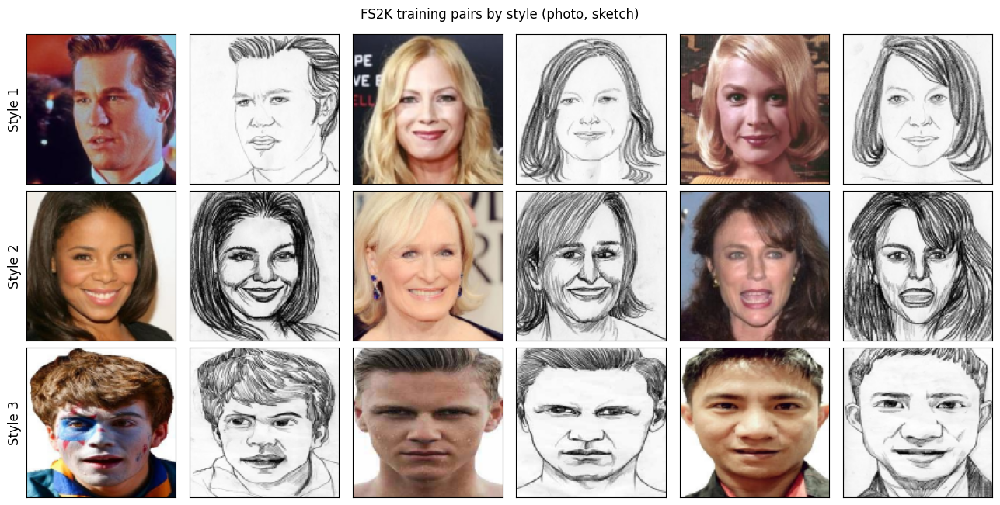

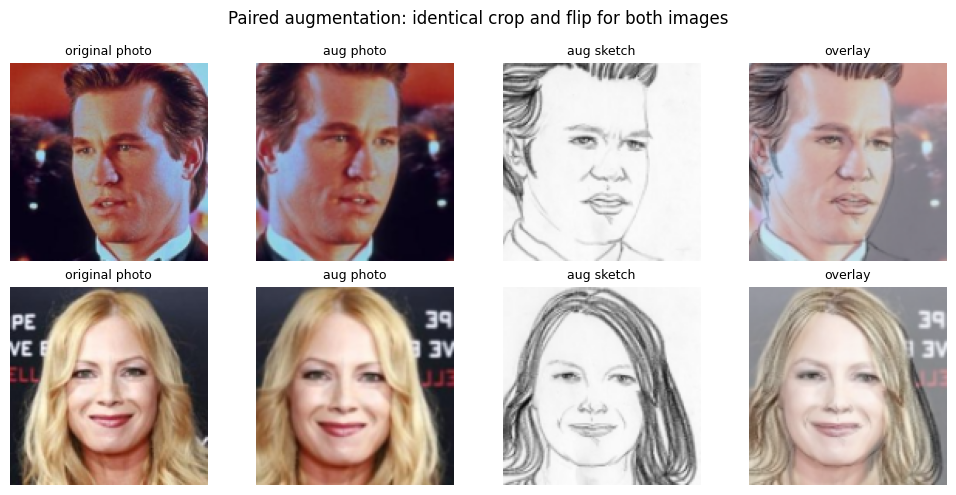

In [9]:
# Dataset figure (3 pairs per style) and a check that augmentation keeps photo and sketch aligned
fig, axes = plt.subplots(3, 6, figsize=(13, 6.6))
for st in range(3):
    ids = np.where(ST[tr_idx] == st)[0][:3]
    for j, i in enumerate(ids):
        axes[st, 2 * j].imshow(P[tr_idx][i]); axes[st, 2 * j + 1].imshow(S[tr_idx][i])
    axes[st, 0].set_ylabel(STYLE_NAMES[st], fontsize=12)
for a in axes.flat: a.set_xticks([]); a.set_yticks([])
fig.suptitle("FS2K training pairs by style (photo, sketch)"); fig.tight_layout()
fig.savefig(f"{T4}/figures/dataset_examples.png", dpi=130); plt.show()

rng = np.random.default_rng(0)
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for r in range(2):
    p, s = paired_augment(P[tr_idx][r], S[tr_idx][r], rng)
    overlay = (0.5 * p + 0.5 * s).astype(np.uint8)
    for a, im, t in zip(axes[r], [P[tr_idx][r], p, s, overlay], ["original photo", "aug photo", "aug sketch", "overlay"]):
        a.imshow(im); a.set_title(t, fontsize=9); a.axis("off")
fig.suptitle("Paired augmentation: identical crop and flip for both images"); fig.tight_layout()
fig.savefig(f"{T4}/figures/paired_augmentation_check.png", dpi=130); plt.show()

## 4. Weights & Biases login and Optuna study

Each trial is a separate W&B run (group `task4-optuna`) that logs discriminator real loss, discriminator fake loss, generator adversarial loss and generator L1 loss separately, plus validation metrics.

**Selection objective:** `val_LPIPS + (1 - val_SSIM)`, fixed for every trial. It does not use the tuned `lambda_L1`, so Optuna cannot improve the score just by changing the loss weighting. LPIPS rewards perceptual similarity (stroke texture), and SSIM rewards facial structure. A pure L1 score would favour very large `lambda_L1` and blurry sketches, which is the known weakness of L1-only image translation.

Trials use 20 epochs; the selected configuration is then retrained for the full schedule (Section 5).

In [11]:
import wandb, lpips
os.environ.setdefault("WANDB_SILENT", "true")
try:
    from google.colab import userdata
    wandb.login(key=userdata.get("WANDB_API_KEY"))
except Exception as e:
    print("Colab secret not found, falling back to interactive login:", e)
    wandb.login()
lpips_fn = lpips.LPIPS(net="alex", verbose=False).to(device).eval()
for p in lpips_fn.parameters():
    p.requires_grad_(False)

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 182MB/s]


In [12]:
import optuna
from torchvision.utils import make_grid

# Fixed validation photos (3 per style) for sample logging across training
FIXED = np.concatenate([np.where(VAL[2].numpy() == st)[0][:3] for st in range(3)])

def make_image_fn(save_dir=None):
    def image_fn(G, epoch):
        x, y, s = VAL[0][FIXED], VAL[1][FIXED], VAL[2][FIXED]
        fake = generate(G, x, s, device)
        grid = make_grid(to_unit(torch.cat([x, fake, y])), nrow=len(FIXED))
        wandb.log({"val_samples": wandb.Image(grid, caption="rows: photo | generated | real sketch "
                   "(columns: 3 x Style 1, 3 x Style 2, 3 x Style 3)"), "epoch": epoch})
        if save_dir:
            torch.save(fake, f"{save_dir}/fixed_val_epoch{epoch:03d}.pt")
    return image_fn

def run(cfg, epochs, name, group, trial=None, ckpt=None, eval_every=5, sample_every=10, save_dir=None):
    seed_everything(SEED)
    r = wandb.init(project=WANDB_PROJECT, name=name, group=group, job_type="task4",
                   config={**cfg, "epochs": epochs}, reinit=True)
    try:
        best, hist, G = fit_gan(cfg, train_ds, VAL, epochs, device, lpips_fn, log_fn=wandb.log,
                                image_fn=make_image_fn(save_dir), trial=trial, ckpt_path=ckpt,
                                eval_every=eval_every, sample_every=sample_every,
                                num_workers=NUM_WORKERS, seed=SEED)
    finally:
        r.finish()
    return best, hist, G

SEARCH_SPACE = {"lr_g": "log-uniform [5e-5, 5e-4]", "lr_d": "log-uniform [2e-5, 5e-4]",
                "batch_size": "{4, 8, 16}", "base_channels": "{32, 48, 64}",
                "dropout": "uniform [0.0, 0.5] (generator decoder)", "style_emb_dim": "{4, 8, 16, 32}",
                "lambda_l1": "log-uniform [10, 200]"}

def objective(trial):
    cfg = {"lr_g": trial.suggest_float("lr_g", 5e-5, 5e-4, log=True),
           "lr_d": trial.suggest_float("lr_d", 2e-5, 5e-4, log=True),
           "batch_size": trial.suggest_categorical("batch_size", [4, 8, 16]),
           "base_channels": trial.suggest_categorical("base_channels", [32, 48, 64]),
           "dropout": trial.suggest_float("dropout", 0.0, 0.5),
           "style_emb_dim": trial.suggest_categorical("style_emb_dim", [4, 8, 16, 32]),
           "lambda_l1": trial.suggest_float("lambda_l1", 10, 200, log=True)}
    best, hist, _ = run(cfg, OPTUNA_EPOCHS, f"t4-trial-{trial.number:03d}", "task4-optuna", trial=trial,
                        eval_every=OPTUNA_EVAL_EVERY, sample_every=OPTUNA_EPOCHS)
    last = [h for h in hist if "val/ssim" in h][-1]
    trial.set_user_attr("val_ssim", last["val/ssim"]); trial.set_user_attr("val_lpips", last["val/lpips"])
    return best

study = optuna.create_study(study_name="task4_cgan", storage=f"sqlite:///{T4}/optuna/task4_study.db",
                            load_if_exists=True, direction="minimize",
                            sampler=optuna.samplers.TPESampler(seed=SEED),
                            pruner=optuna.pruners.MedianPruner(n_startup_trials=4, n_warmup_steps=2 * OPTUNA_EVAL_EVERY))
if len(study.trials) == 0:   # trial 0 = the standard pix2pix settings, as a reference point
    study.enqueue_trial({"lr_g": 2e-4, "lr_d": 2e-4, "batch_size": 8, "base_channels": 64,
                         "dropout": 0.5, "style_emb_dim": 8, "lambda_l1": 100.0})
done = len([t for t in study.trials if t.state.name in ("COMPLETE", "PRUNED")])
study.optimize(objective, n_trials=max(0, OPTUNA_TRIALS - done), gc_after_trial=True)

[I 2026-10-04 09:23:37,182] A new study created in RDB with name: task4_cgan


ep 004 | D real 0.382 fake 0.353 | G adv 1.895 L1 0.2446 | val SSIM 0.4032 LPIPS 0.5202 obj 1.1169
ep 008 | D real 0.449 fake 0.393 | G adv 1.660 L1 0.2301 | val SSIM 0.4214 LPIPS 0.4258 obj 1.0044
ep 012 | D real 0.449 fake 0.403 | G adv 1.616 L1 0.2220 | val SSIM 0.4412 LPIPS 0.3368 obj 0.8956
ep 016 | D real 0.383 fake 0.354 | G adv 1.594 L1 0.2136 | val SSIM 0.4514 LPIPS 0.2888 obj 0.8373
ep 020 | D real 0.337 fake 0.311 | G adv 1.524 L1 0.2089 | val SSIM 0.4400 LPIPS 0.2708 obj 0.8308


[I 2026-10-04 09:27:49,998] Trial 0 finished with value: 0.8308171331882477 and parameters: {'lr_g': 0.0002, 'lr_d': 0.0002, 'batch_size': 8, 'base_channels': 64, 'dropout': 0.5, 'style_emb_dim': 8, 'lambda_l1': 100.0}. Best is trial 0 with value: 0.8308171331882477.


ep 004 | D real 0.611 fake 0.599 | G adv 1.271 L1 0.2572 | val SSIM 0.2949 LPIPS 0.5003 obj 1.2054
ep 008 | D real 0.620 fake 0.617 | G adv 1.599 L1 0.2419 | val SSIM 0.4200 LPIPS 0.3317 obj 0.9117
ep 012 | D real 0.462 fake 0.449 | G adv 1.699 L1 0.2396 | val SSIM 0.3868 LPIPS 0.2862 obj 0.8994
ep 016 | D real 0.369 fake 0.365 | G adv 1.882 L1 0.2316 | val SSIM 0.4220 LPIPS 0.2611 obj 0.8391
ep 020 | D real 0.263 fake 0.258 | G adv 1.845 L1 0.2277 | val SSIM 0.4228 LPIPS 0.2574 obj 0.8346


[I 2026-10-04 09:34:37,255] Trial 1 finished with value: 0.8346366584300995 and parameters: {'lr_g': 0.00011844319751820385, 'lr_d': 0.00042664981476167217, 'batch_size': 4, 'base_channels': 64, 'dropout': 0.3005575058716044, 'style_emb_dim': 16, 'lambda_l1': 18.891200276189384}. Best is trial 0 with value: 0.8308171331882477.


...

[I 2026-10-04 10:01:46,894] Trial 13 finished with value: 0.8258883059024811 and parameters: {'lr_g': 0.00035601188242815533, 'lr_d': 0.00027965829511974154, 'batch_size': 8, 'base_channels': 48, 'dropout': 0.47822253556693517, 'style_emb_dim': 4, 'lambda_l1': 23.46484061310344}. Best is trial 12 with value: 0.8122401833534241.


ep 004 | D real 0.590 fake 0.581 | G adv 1.255 L1 0.2732 | val SSIM 0.3342 LPIPS 0.5148 obj 1.1805


[I 2026-10-04 10:03:00,224] Trial 14 pruned. 


ep 004 | D real 0.392 fake 0.357 | G adv 1.819 L1 0.2459 | val SSIM 0.4114 LPIPS 0.5180 obj 1.1065


[I 2026-10-04 10:04:55,628] Trial 15 pruned. 


Trial states: {'COMPLETE': 8, 'PRUNED': 8}
Best trial #12: objective 0.8122
Best config: {'lr_g': 0.0004776148201168527, 'lr_d': 0.0003787340625619012, 'batch_size': 8, 'base_channels': 48, 'dropout': 0.4322165582594886, 'style_emb_dim': 4, 'lambda_l1': 23.342943449791612}


/tmp/ipykernel_429/1420593570.py:14: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = fn(study)


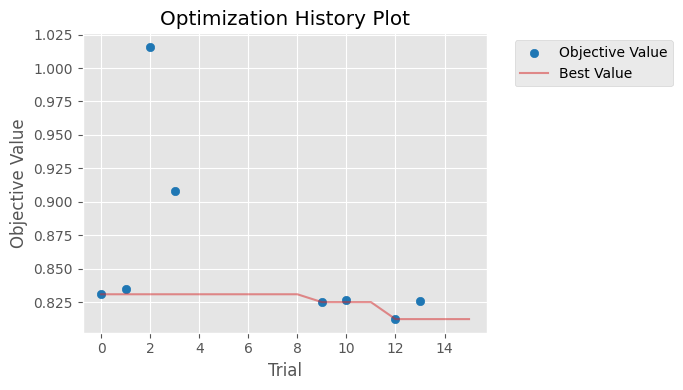

/tmp/ipykernel_429/1420593570.py:14: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ax = fn(study)


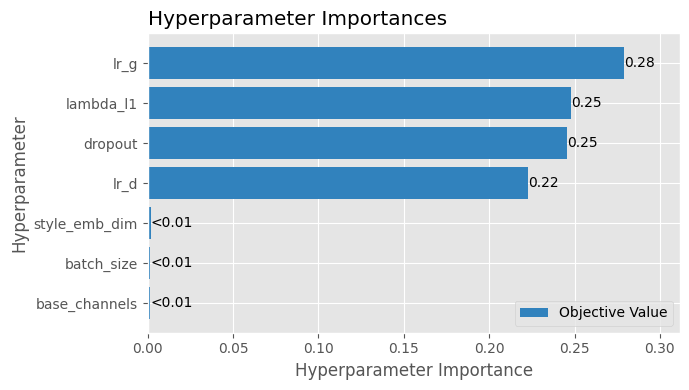

/tmp/ipykernel_429/1420593570.py:14: ExperimentalWarning: optuna.visualization.matplotlib._slice.plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  ax = fn(study)
/tmp/ipykernel_429/1420593570.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.set_size_inches(14 if name == "slice" else 7, 4); fig.tight_layout()


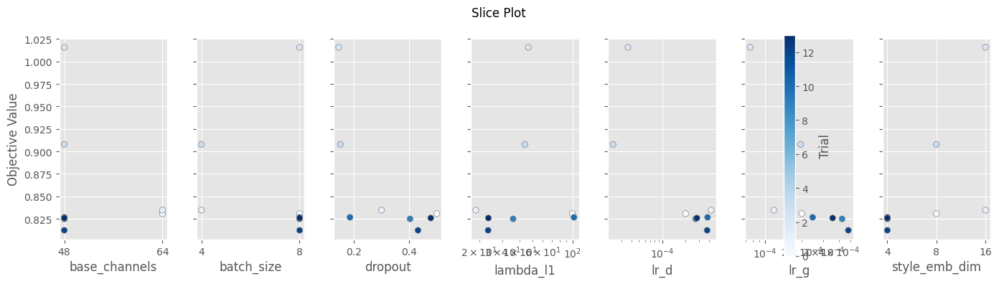

In [13]:
states = pd.Series([t.state.name for t in study.trials]).value_counts().to_dict()
best_t = study.best_trial
BEST_CFG = dict(best_t.params)
print("Trial states:", states)
print(f"Best trial #{best_t.number}: objective {best_t.value:.4f}"); print("Best config:", BEST_CFG)
study.trials_dataframe().to_csv(f"{T4}/optuna/trials.csv", index=False)
json.dump({"search_space": SEARCH_SPACE, "objective": "val_LPIPS + (1 - val_SSIM)",
           "trial_epochs": OPTUNA_EPOCHS, "n_trials": len(study.trials), "states": states,
           "best_trial": best_t.number, "best_value": best_t.value, "best_params": BEST_CFG},
          open(f"{T4}/optuna/study_summary.json", "w"), indent=2)
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances, plot_slice
for name, fn in [("history", plot_optimization_history), ("importance", plot_param_importances), ("slice", plot_slice)]:
    try:
        ax = fn(study)
        fig = ax.figure if hasattr(ax, "figure") else ax.flatten()[0].figure
        fig.set_size_inches(14 if name == "slice" else 7, 4); fig.tight_layout()
        fig.savefig(f"{T4}/optuna/{name}.png", dpi=150); plt.show()
    except Exception as e:
        print(f"Could not plot {name}: {e}")

## 5. Final training with the selected configuration

200 epochs: constant learning rate for 100 epochs, then linear decay to zero (the pix2pix schedule). Validation every 5 epochs; the checkpoint with the best validation objective is kept. GAN losses do not decrease steadily the way a reconstruction loss does, so the checkpoint is chosen on validation quality rather than on training loss. The same 9 validation photos are generated every 10 epochs, logged to W&B and saved to Drive for the "generator over time" figure.

In [14]:
FINAL_CKPT = f"{T4}/checkpoints/generator_best.pt"
best_obj, final_hist, G = run(BEST_CFG, FINAL_EPOCHS, "t4-final", "task4-final", ckpt=FINAL_CKPT,
                              eval_every=FINAL_EVAL_EVERY, sample_every=SAMPLE_EVERY, save_dir=f"{T4}/samples")
pd.DataFrame(final_hist).to_csv(f"{T4}/results/final_history.csv", index=False)
print("Best validation objective:", round(best_obj, 4))

ep 005 | D real 0.622 fake 0.600 | G adv 1.098 L1 0.2516 | val SSIM 0.4199 LPIPS 0.4143 obj 0.9944
ep 010 | D real 0.587 fake 0.571 | G adv 1.202 L1 0.2338 | val SSIM 0.4124 LPIPS 0.2860 obj 0.8736
ep 015 | D real 0.666 fake 0.636 | G adv 0.888 L1 0.2133 | val SSIM 0.4524 LPIPS 0.2602 obj 0.8078
ep 020 | D real 0.602 fake 0.593 | G adv 1.154 L1 0.2187 | val SSIM 0.4179 LPIPS 0.2505 obj 0.8325
ep 025 | D real 0.582 fake 0.575 | G adv 1.193 L1 0.2126 | val SSIM 0.4521 LPIPS 0.2359 obj 0.7838
ep 030 | D real 0.584 fake 0.577 | G adv 1.202 L1 0.2100 | val SSIM 0.4419 LPIPS 0.2333 obj 0.7914
ep 035 | D real 0.582 fake 0.571 | G adv 1.289 L1 0.2082 | val SSIM 0.4622 LPIPS 0.2242 obj 0.7620
ep 040 | D real 0.567 fake 0.569 | G adv 1.193 L1 0.2051 | val SSIM 0.4251 LPIPS 0.2294 obj 0.8043
ep 045 | D real 0.568 fake 0.563 | G adv 1.314 L1 0.2038 | val SSIM 0.4638 LPIPS 0.2173 obj 0.7535
ep 050 | D real 0.571 fake 0.555 | G adv 1.275 L1 0.1996 | val SSIM 0.4745 LPIPS 0.2093 obj 0.7348
ep 055 | D

## 6. Training curves and generator development

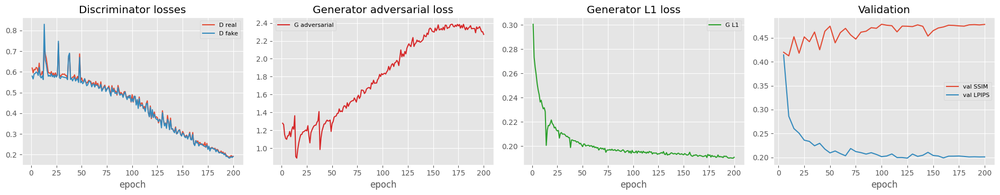

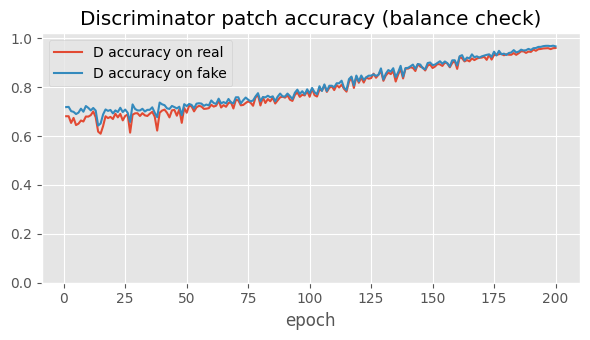

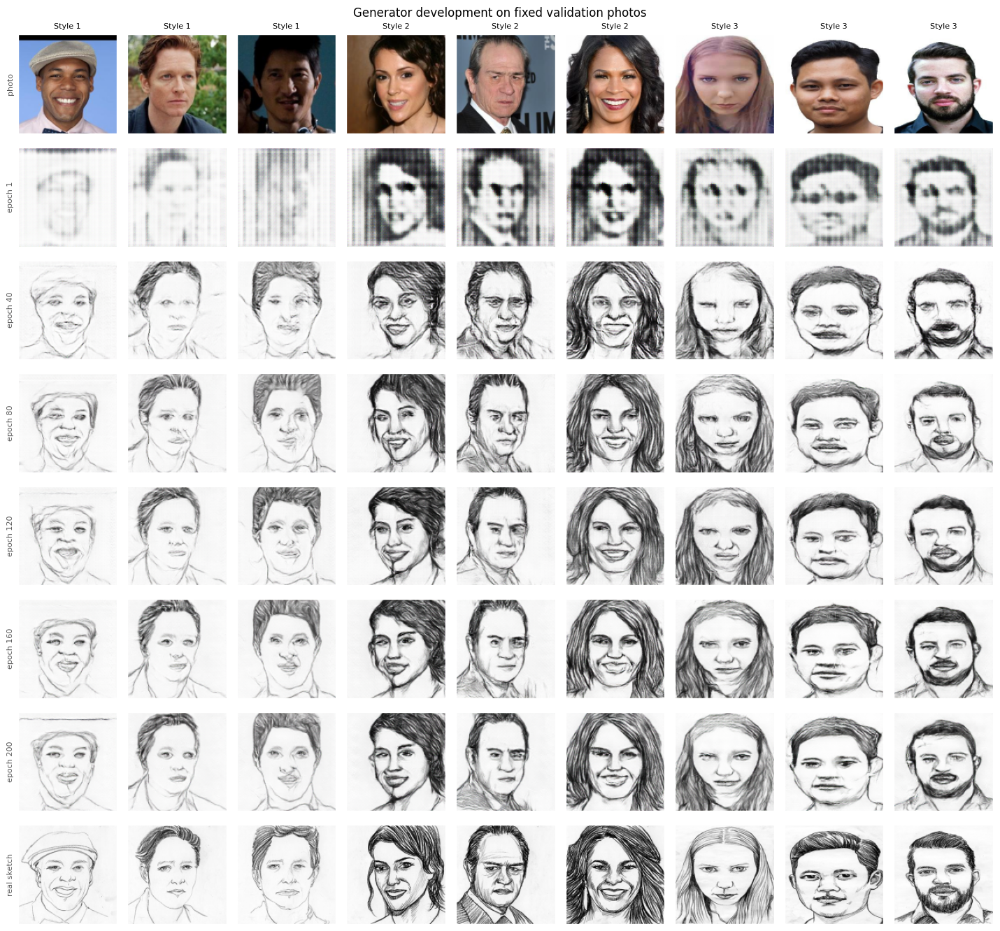

In [15]:
h = pd.DataFrame(final_hist)
v = h.dropna(subset=["val/ssim"])
fig, ax = plt.subplots(1, 4, figsize=(19, 3.8))
ax[0].plot(h.epoch, h["train/d_real"], label="D real"); ax[0].plot(h.epoch, h["train/d_fake"], label="D fake")
ax[0].set_title("Discriminator losses")
ax[1].plot(h.epoch, h["train/g_adv"], label="G adversarial", color="tab:red"); ax[1].set_title("Generator adversarial loss")
ax[2].plot(h.epoch, h["train/g_l1"], label="G L1", color="tab:green"); ax[2].set_title("Generator L1 loss")
ax[3].plot(v.epoch, v["val/ssim"], label="val SSIM"); ax[3].plot(v.epoch, v["val/lpips"], label="val LPIPS")
ax[3].set_title("Validation")
for a in ax: a.set_xlabel("epoch"); a.legend(fontsize=8)
fig.tight_layout(); fig.savefig(f"{T4}/figures/training_curves.png", dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(h.epoch, h["train/d_acc_real"], label="D accuracy on real"); ax.plot(h.epoch, h["train/d_acc_fake"], label="D accuracy on fake")
ax.set_ylim(0, 1.02); ax.set_xlabel("epoch"); ax.legend(); ax.set_title("Discriminator patch accuracy (balance check)")
fig.tight_layout(); fig.savefig(f"{T4}/figures/discriminator_accuracy.png", dpi=150); plt.show()

saved = sorted(glob.glob(f"{T4}/samples/fixed_val_epoch*.pt"))
pick = [saved[i] for i in np.unique(np.linspace(0, len(saved) - 1, min(6, len(saved))).astype(int))]
x, y = VAL[0][FIXED], VAL[1][FIXED]
fig, axes = plt.subplots(len(pick) + 2, len(FIXED), figsize=(1.6 * len(FIXED), 1.7 * (len(pick) + 2)))
for j in range(len(FIXED)):
    axes[0, j].imshow(to_unit(x[j]).permute(1, 2, 0))
    for r, f in enumerate(pick):
        axes[r + 1, j].imshow(to_unit(torch.load(f)[j]).permute(1, 2, 0))
    axes[-1, j].imshow(to_unit(y[j]).permute(1, 2, 0))
    axes[0, j].set_title(STYLE_NAMES[int(VAL[2][FIXED][j])], fontsize=8)
labels = ["photo"] + [f"epoch {int(os.path.basename(f)[15:18])}" for f in pick] + ["real sketch"]
for r, l in enumerate(labels):
    axes[r, 0].set_ylabel(l, fontsize=8)
for a in axes.flat: a.set_xticks([]); a.set_yticks([])
fig.suptitle("Generator development on fixed validation photos"); fig.tight_layout()
fig.savefig(f"{T4}/figures/generator_over_time.png", dpi=130); plt.show()

## 7. Test evaluation

The official test set is used here for the first time, with each photo conditioned on its true style.

Metrics: L1, PSNR and SSIM (pixel and structure), LPIPS (perceptual), FID and KID (distribution of generated vs real sketches, Inception features). KID is included because FID is biased for small sets, and the test set has only 46 Style 3 images. Per-style FID and KID are therefore reported with that caveat.

The style analysis checks that the embedding actually controls the output: each test photo is generated in all three styles, and the result under the true style should match the real sketch better than the results under the other two styles.

In [16]:
ckpt = torch.load(FINAL_CKPT, map_location="cpu", weights_only=False)
BEST_CFG = ckpt["config"]
G, _ = build_models(BEST_CFG); G.load_state_dict(ckpt["G"]); G = G.to(device).eval()
print(f"Loaded generator from epoch {ckpt['epoch']} | G params {count_params(G):,}")

summary, per, test_fake = evaluate_generator(G, *TEST, device, lpips_fn)
res = pd.DataFrame({k: v.numpy() for k, v in per.items()})
res["style"] = [STYLE_NAMES[s] for s in TEST[2].numpy()]
res["name"] = data["test_names"]
res.to_csv(f"{T4}/results/test_per_sample.csv", index=False)

from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance

def fid_kid(real, fake):
    n = len(real)
    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
    kid = KernelInceptionDistance(subset_size=min(50, n), normalize=True).to(device)
    for i in range(0, n, 64):
        r, f = to_unit(real[i:i + 64]).to(device), to_unit(fake[i:i + 64]).to(device)
        fid.update(r, real=True); fid.update(f, real=False); kid.update(r, real=True); kid.update(f, real=False)
    km, ks = kid.compute()
    return float(fid.compute()), float(km), float(ks)

rows = []
for name, sel in [("Overall", np.ones(len(res), bool))] + [(s, (res["style"] == s).values) for s in STYLE_NAMES]:
    r = {"subset": name, "n": int(sel.sum()), **{k.upper(): res.loc[sel, k].mean() for k in ("l1", "psnr", "ssim", "lpips")}}
    try:
        r["FID"], r["KID_mean"], r["KID_std"] = fid_kid(TEST[1][sel], test_fake[sel])
    except Exception as e:
        print(f"FID/KID failed for {name}: {e}")
    rows.append(r)
test_tbl = pd.DataFrame(rows).set_index("subset")
test_tbl.to_csv(f"{T4}/results/test_metrics.csv")
with open(f"{T4}/results/test_metrics.tex", "w") as f:
    f.write(test_tbl.to_latex(float_format="%.4f"))
display(test_tbl.round(4))

Loaded generator from epoch 200 | G params 23,560,095


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 235MB/s]
/usr/local/lib/python3.13/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


,n,L1,PSNR,SSIM,LPIPS,FID,KID_mean,KID_std
subset,,,,,,,,
Overall,1046,0.1066,15.537400,0.4628,0.2107,37.5761,0.0302,0.0033
Style 1,619,0.0816,17.242001,0.5043,0.2141,42.3085,0.0330,0.0036
Style 2,381,0.1517,12.458000,0.3799,0.2109,46.8207,0.0398,0.0045
Style 3,46,0.0693,18.104900,0.5908,0.1640,80.3354,0.0460,0.0000


In [17]:
# Does the style embedding control the output? Generate every test photo in all three styles.
outs = [generate(G, TEST[0], torch.full_like(TEST[2], st), device) for st in range(3)]
ssim_by = torch.stack([per_sample_metrics(o, TEST[1])["ssim"] for o in outs], 1)     # (N, 3)
lp_by = torch.stack([per_sample_metrics(o, TEST[1], lpips_fn, device)["lpips"] for o in outs], 1)
true = TEST[2]
rows = []
for st in range(3):
    sel = true == st
    rows.append({"true style": STYLE_NAMES[st], "n": int(sel.sum()),
                 **{f"SSIM as {STYLE_NAMES[k]}": float(ssim_by[sel, k].mean()) for k in range(3)},
                 **{f"LPIPS as {STYLE_NAMES[k]}": float(lp_by[sel, k].mean()) for k in range(3)},
                 "best LPIPS is true style (%)": float((lp_by[sel].argmin(1) == st).float().mean() * 100)})
style_tbl = pd.DataFrame(rows).set_index("true style")
pair_diff = {f"{STYLE_NAMES[a]} vs {STYLE_NAMES[b]}": float((to_unit(outs[a]) - to_unit(outs[b])).abs().mean())
             for a in range(3) for b in range(a + 1, 3)}
style_tbl.to_csv(f"{T4}/results/style_control.csv")
with open(f"{T4}/results/style_control.tex", "w") as f:
    f.write(style_tbl.to_latex(float_format="%.3f"))
display(style_tbl.round(3))
print("Mean absolute difference between outputs for the same photo under different styles:",
      {k: round(v, 4) for k, v in pair_diff.items()})
print("If these differences are near 0, the generator is ignoring the style condition.")

,n,SSIM as Style 1,SSIM as Style 2,SSIM as Style 3,LPIPS as Style 1,LPIPS as Style 2,LPIPS as Style 3,best LPIPS is true style (%)
true style,,,,,,,,
Style 1,619,0.504,0.434,0.479,0.214,0.258,0.235,72.859
Style 2,381,0.336,0.380,0.357,0.294,0.211,0.242,90.814
Style 3,46,0.563,0.554,0.591,0.203,0.192,0.164,95.652


Mean absolute difference between outputs for the same photo under different styles: {'Style 1 vs Style 2': 0.1149, 'Style 1 vs Style 3': 0.1078, 'Style 2 vs Style 3': 0.0953}
If these differences are near 0, the generator is ignoring the style condition.


## 8. Visual results and failure cases

Representative results are the test images closest to the median LPIPS of each style (typical, not best). Each row shows the photo, the real sketch, the sketch generated with the true style, and the same photo in the other two styles. Failure cases are the highest-LPIPS test images.

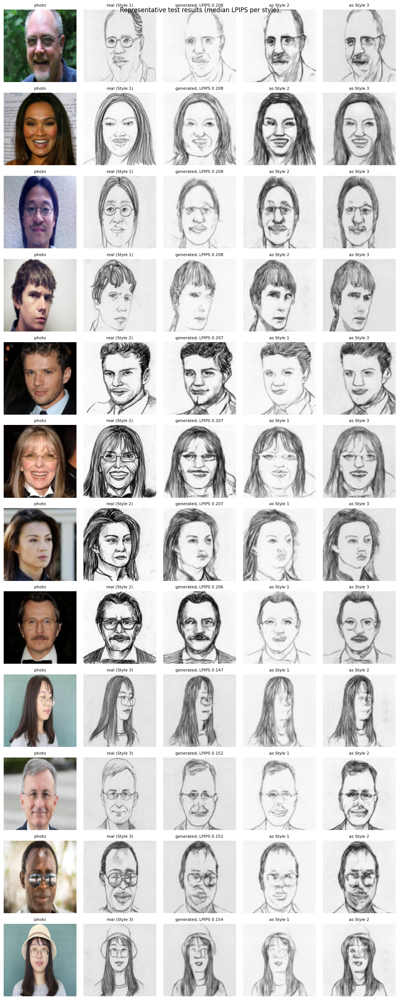

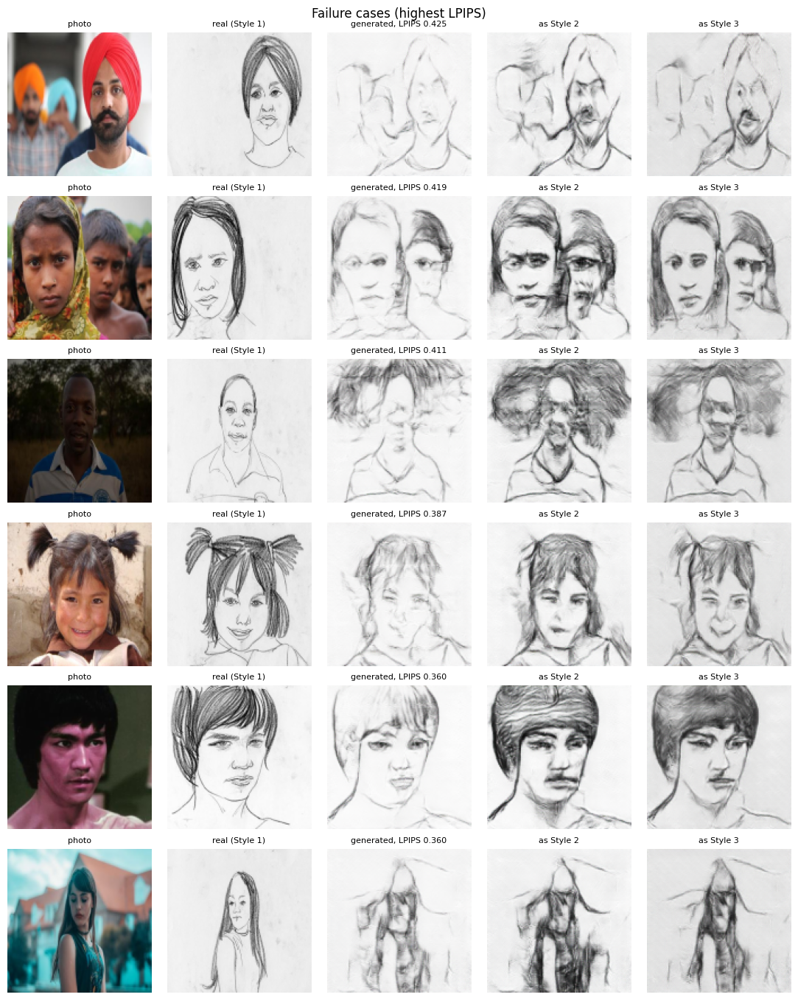

In [18]:
def show_rows(idx, title, path):
    fig, axes = plt.subplots(len(idx), 5, figsize=(11, 2.3 * len(idx)))
    for r, i in enumerate(idx):
        st = int(TEST[2][i])
        panels = [(TEST[0][i], "photo"), (TEST[1][i], f"real ({STYLE_NAMES[st]})"),
                  (outs[st][i], f"generated, LPIPS {lp_by[i, st]:.3f}")]
        panels += [(outs[k][i], f"as {STYLE_NAMES[k]}") for k in range(3) if k != st]
        for a, (im, t) in zip(axes[r], panels):
            a.imshow(to_unit(im).permute(1, 2, 0)); a.set_title(t, fontsize=8); a.axis("off")
    fig.suptitle(title); fig.tight_layout(); fig.savefig(path, dpi=120); plt.show()

rep = []
for s in STYLE_NAMES:
    sub = res[res["style"] == s]
    rep += list(sub.iloc[(sub.lpips - sub.lpips.median()).abs().argsort().values[:4]].index)
show_rows(rep, "Representative test results (median LPIPS per style)", f"{T4}/figures/representative_results.png")
show_rows(list(res.sort_values("lpips", ascending=False).index[:6]), "Failure cases (highest LPIPS)",
          f"{T4}/figures/failure_cases.png")

## 9. ONNX export of the generator

Only the generator is exported; the discriminator is a training component. The wrapper takes `photo` (N, 3, 128, 128) RGB in [0, 1] and `style` (N,) int64 in {0, 1, 2}, and returns `sketch` in [0, 1], so the backend does no scaling of its own. The model runs in eval mode, so dropout is off and the output is deterministic.

In [19]:
import onnx, onnxruntime as ort
ONNX_PATH = f"{T4}/onnx/face2sketch_generator.onnx"
Gc, _ = build_models(BEST_CFG); Gc.load_state_dict(ckpt["G"]); Gc.eval()
wrapper = SketchExportWrapper(Gc).eval()
dummy = (torch.rand(1, 3, IMG_SIZE, IMG_SIZE), torch.zeros(1, dtype=torch.long))
torch.onnx.export(wrapper, dummy, ONNX_PATH, input_names=["photo", "style"], output_names=["sketch"],
                  opset_version=17, dynamic_axes={"photo": {0: "batch"}, "style": {0: "batch"}, "sketch": {0: "batch"}},
                  dynamo=False)
onnx.checker.check_model(onnx.load(ONNX_PATH))
sess = ort.InferenceSession(ONNX_PATH, providers=["CPUExecutionProvider"])

n = min(60, len(TEST[0]))
xs, ss = to_unit(TEST[0][:n]), TEST[2][:n]
diffs = []
for st in range(3):                   # check every style, not only the true one
    sty = torch.full_like(ss, st)
    with torch.no_grad():
        pt = wrapper(xs, sty).numpy()
    ox = sess.run(None, {"photo": xs.numpy(), "style": sty.numpy()})[0]
    diffs.append(float(np.abs(pt - ox).max()))
print("Max |PyTorch - ONNX| per style on", n, "test photos:", diffs)
assert max(diffs) < 1e-4, "ONNX output does not match PyTorch"

one = {"photo": xs[:1].numpy(), "style": np.array([0], dtype=np.int64)}
for _ in range(5): sess.run(None, one)
lat = []
for _ in range(50):
    t0 = time.perf_counter(); sess.run(None, one); lat.append((time.perf_counter() - t0) * 1000)
print(f"ONNX Runtime CPU latency (batch 1): mean {np.mean(lat):.1f} ms, p95 {np.percentile(lat, 95):.1f} ms")

meta = {"task": "face_to_sketch", "onnx_file": os.path.basename(ONNX_PATH),
        "inputs": {"photo": {"shape": [None, 3, IMG_SIZE, IMG_SIZE], "range": [0, 1], "layout": "NCHW RGB float32"},
                   "style": {"shape": [None], "dtype": "int64", "values": {"0": "Style 1", "1": "Style 2", "2": "Style 3"}}},
        "outputs": {"sketch": {"shape": [None, 3, IMG_SIZE, IMG_SIZE], "range": [0, 1]}},
        "style_names": STYLE_NAMES, "preprocessing": "convert to RGB, resize to 128x128 (INTER_AREA), scale to [0,1]",
        "config": BEST_CFG, "opset": 17, "onnx_vs_pytorch_max_abs_diff": max(diffs),
        "cpu_latency_ms_batch1": {"mean": float(np.mean(lat)), "p95": float(np.percentile(lat, 95))},
        "test": test_tbl.loc["Overall"].to_dict()}
json.dump(meta, open(f"{T4}/onnx/task4_metadata.json", "w"), indent=2, default=float)
print("Saved", ONNX_PATH, f"({os.path.getsize(ONNX_PATH) / 1e6:.1f} MB)")

/tmp/ipykernel_429/2129992298.py:6: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(wrapper, dummy, ONNX_PATH, input_names=["photo", "style"], output_names=["sketch"],


Max |PyTorch - ONNX| per style on 60 test photos: [1.6093254089355469e-06, 2.7418136596679688e-06, 1.7881393432617188e-06]
ONNX Runtime CPU latency (batch 1): mean 25.5 ms, p95 29.7 ms
Saved /content/drive/MyDrive/genai-assignment1/task4/onnx/face2sketch_generator.onnx (94.3 MB)


## 10. Log results and files to W&B

In [ ]:
def flat(df):
    d = df.round(4).copy(); d.columns = [str(c) for c in d.columns]; d.index = [str(i) for i in d.index]
    return d.reset_index(names="group")

r = wandb.init(project=WANDB_PROJECT, name="t4-test-and-export", group="task4-final", job_type="task4-eval", reinit=True)
wandb.log({"test/metrics": wandb.Table(dataframe=flat(test_tbl)), "test/style_control": wandb.Table(dataframe=flat(style_tbl)),
           "data/split_counts": wandb.Table(dataframe=flat(split_tbl))})
for f in sorted(glob.glob(f"{T4}/figures/*.png")):
    wandb.log({f"figures/{os.path.basename(f)[:-4]}": wandb.Image(f)})
wandb.summary.update({f"test_{k}": v for k, v in test_tbl.loc["Overall"].items()})
wandb.summary["onnx_latency_ms"] = float(np.mean(lat))
art = wandb.Artifact("task4-face2sketch", type="model")
for f in [FINAL_CKPT, ONNX_PATH, f"{T4}/onnx/task4_metadata.json", f"{T4}/optuna/study_summary.json", SPLIT_PATH]:
    art.add_file(f)
art.add_dir(f"{T4}/results", name="results")
r.log_artifact(art); r.finish()
print("Task 4 complete. Everything is in", T4)